# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/24f2001824/ml-flyrank/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

## Research question

Can observable content, visibility, freshness, and engagement signals be used to rank pages for human review and content-refresh actions?

## Decision supported

The goal is to help a content team decide which pages should be reviewed first for possible refresh, expansion, or monitoring.

This is a decision-support problem. The ranking does not claim that a refresh will cause traffic to increase.

In [88]:
analysis_goal = {
    "lane": "Refresh / Content Opportunity Scoring",
    "decision": "Prioritize pages for human review and possible content-refresh actions",
    "unit_of_analysis": "Page",
    "output": "Ranked list of pages with recommended review actions"
}

analysis_goal

{'lane': 'Refresh / Content Opportunity Scoring',
 'decision': 'Prioritize pages for human review and possible content-refresh actions',
 'unit_of_analysis': 'Page',
 'output': 'Ranked list of pages with recommended review actions'}

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## Data used

This project uses the FlyRank ML Internship anonymized content-refresh dataset.

The analysis is performed at the page level. The dataset contains anonymized page identifiers, content characteristics, search visibility metrics, engagement metrics, freshness information, and trend information.

The analysis uses the available 90-day performance fields together with content age and freshness fields. No client names, domains, URLs, private search queries, page titles, or raw client exports are used.

The target label is derived from the observed trend direction. Pages with a downward trend are treated as declining pages for the modelling task.

## Exclusions

The following fields are excluded from the model features:

- content_id and client_id: identifiers rather than content signals.
- trend_direction: used to create the target label.
- trend_pct: directly describes the observed trend and could leak information about the target.

No private client information or identifying content is included in the analysis.

In [89]:
import pandas as pd
!git clone https://github.com/24f2001824/ml-flyrank.git

data_path = "/content/ml-flyrank/data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(data_path)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nDataset columns:")
print(df.columns.tolist())

fatal: destination path 'ml-flyrank' already exists and is not an empty directory.
Rows: 30000
Columns: 44

Dataset columns:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']


In [90]:
df["is_declining_label"] = (
    df["trend_direction"].str.lower() == "down"
).astype(int)

print("Declining pages:", df["is_declining_label"].sum())
print("Non-declining pages:", (df["is_declining_label"] == 0).sum())

Declining pages: 16262
Non-declining pages: 13738


In [91]:
data_groups = {
    "Content": [
        "word_count",
        "char_count",
        "content_type",
        "main_intent"
    ],
    "Visibility": [
        "impressions_90d",
        "clicks_90d",
        "avg_position",
        "ctr"
    ],
    "Engagement": [
        "pageviews_90d",
        "sessions_90d",
        "users_90d",
        "engaged_sessions_90d",
        "engagement_rate",
        "scroll_rate"
    ],
    "Freshness": [
        "content_age_days",
        "days_since_last_update",
        "freshness_tier"
    ]
}

data_groups

{'Content': ['word_count', 'char_count', 'content_type', 'main_intent'],
 'Visibility': ['impressions_90d', 'clicks_90d', 'avg_position', 'ctr'],
 'Engagement': ['pageviews_90d',
  'sessions_90d',
  'users_90d',
  'engaged_sessions_90d',
  'engagement_rate',
  'scroll_rate'],
 'Freshness': ['content_age_days', 'days_since_last_update', 'freshness_tier']}

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

The analysis treats each page as one observation.

The target label is `is_declining_label`, defined as 1 when the observed `trend_direction` is `down`, and 0 otherwise.

The model uses content, visibility, engagement, and freshness signals that are available for the page. Identifiers and fields used directly to define the target are excluded.

The transparent baseline uses simple rules based on visibility, freshness, position, content depth, CTR, and engagement signals. The learned model is then compared with this baseline using the same held-out data.

A client-level holdout is used for validation so that pages from the same client are not split between training and test data. This reduces the risk that the model is evaluated on pages that are too similar to pages it has already seen.

The main ranking metric is Precision@50 because the practical use case is to give a content team a small ranked queue of pages for human review.

A leakage audit is performed before interpreting the model results. Fields such as trend_direction, trend_pct, content_id, and client_id are not used as model features.

The results are treated as directional decision-support findings. They do not establish that refreshing a page will cause traffic or ranking improvements.

In [92]:
features = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "users_90d",
    "engaged_sessions_90d",
    "scroll_events_90d",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct",
    "content_type",
    "main_intent"
]

X = df[features]
y = df["is_declining_label"]

print("Number of features:", len(features))
print("Rows:", X.shape[0])

Number of features: 21
Rows: 30000


In [93]:
excluded_features = [
    "trend_direction",
    "trend_pct",
    "content_id",
    "client_id"
]

leakage_table = pd.DataFrame({
    "field": excluded_features,
    "reason": [
        "Used to define the target label",
        "Direct trend information related to the target",
        "Identifier, not a content signal",
        "Identifier, not a content signal"
    ]
})

leakage_table

,field,reason
0,trend_direction,Used to define the target label
1,trend_pct,Direct trend information related to the target
2,content_id,"Identifier, not a content signal"
3,client_id,"Identifier, not a content signal"


In [94]:
print("Unique clients:", df["client_id"].nunique())
print("Pages per client - median:", df.groupby("client_id").size().median())
print("Pages per client - mean:", df.groupby("client_id").size().mean())

Unique clients: 32
Pages per client - median: 567.0
Pages per client - mean: 937.5


In [95]:
from sklearn.model_selection import GroupShuffleSplit

groups = df["client_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

train_clients = set(df.iloc[train_idx]["client_id"])
test_clients = set(df.iloc[test_idx]["client_id"])

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Training clients:", len(train_clients))
print("Test clients:", len(test_clients))
print("Client overlap:", len(train_clients.intersection(test_clients)))

Training rows: 23837
Test rows: 6163
Training clients: 25
Test clients: 7
Client overlap: 0


In [96]:
split_summary = pd.DataFrame({
    "split": ["Train", "Test"],
    "rows": [len(y_train), len(y_test)],
    "declining": [y_train.sum(), y_test.sum()],
    "declining_pct": [
        y_train.mean() * 100,
        y_test.mean() * 100
    ]
})

split_summary

,split,rows,declining,declining_pct
0,Train,23837,13113,55.011117
1,Test,6163,3149,51.095246


In [97]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

pipeline.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


In [98]:
model_probabilities = pipeline.predict_proba(X_test)[:, 1]

model_results = pd.DataFrame({
    "content_id": df.iloc[test_idx]["content_id"].values,
    "actual_label": y_test.values,
    "model_score": model_probabilities
})

model_results = model_results.sort_values(
    "model_score",
    ascending=False
).reset_index(drop=True)

model_results.head()

,content_id,actual_label,model_score
0,content_29884c0f9255,1,0.950000
1,content_d9786af0ac7b,0,0.946667
2,content_bb1edbf0ba6c,1,0.943333
3,content_db74537c5636,1,0.936667
4,content_7766ffacdcfa,1,0.936667


In [99]:
def precision_at_k(results, score_column, k=50):
    ranked = results.sort_values(
        score_column,
        ascending=False
    ).head(k)

    return ranked["actual_label"].mean()

model_p50 = precision_at_k(
    model_results,
    "model_score",
    50
)

print(f"Model Precision@50: {model_p50:.4f}")

Model Precision@50: 0.6200


In [100]:
import numpy as np

def percentile_rank(series):
    return series.rank(pct=True).fillna(0)

def normalize(series):
    minimum = series.min()
    maximum = series.max()
    if maximum == minimum:
        return pd.Series(0.0, index=series.index)
    return ((series - minimum) / (maximum - minimum)).fillna(0)

baseline = df.iloc[test_idx].copy()

visibility_score = percentile_rank(
    np.log1p(baseline["impressions_90d"])
)

freshness_risk_score = percentile_rank(
    baseline["days_since_last_update"]
)

position_score = (
    1 - normalize(
        baseline["avg_position"].clip(1, 50)
    )
) * visibility_score * (
    baseline["avg_position"] > 0
)

depth_gap_score = (
    1 - percentile_rank(baseline["word_count"])
) * visibility_score

baseline["baseline_refresh_score"] = (
    0.40 * visibility_score
    + 0.30 * freshness_risk_score
    + 0.25 * position_score
    + 0.05 * depth_gap_score
)

print("Baseline scores created successfully.")
print("Rows:", len(baseline))

Baseline scores created successfully.
Rows: 6163


In [101]:
baseline_results = baseline[[
    "content_id",
    "baseline_refresh_score"
]].copy()

baseline_results["actual_label"] = y_test.values

baseline_p50 = precision_at_k(
    baseline_results,
    "baseline_refresh_score",
    50
)

print(f"Baseline Precision@50: {baseline_p50:.4f}")

Baseline Precision@50: 0.3200


In [102]:
comparison = pd.DataFrame({
    "method": [
        "Transparent baseline",
        "Random Forest model"
    ],
    "Precision@50": [
        baseline_p50,
        model_p50
    ]
})

comparison

,method,Precision@50
0,Transparent baseline,0.32
1,Random Forest model,0.62


In [103]:
lift = model_p50 / baseline_p50

print(f"Precision@50 lift: {lift:.2f}x")

Precision@50 lift: 1.94x


### Validation result

The client-level split produced 23,837 training pages from 25 clients and 6,163 test pages from 7 clients, with no client overlap between the two sets.

The Random Forest model achieved a measured Precision@50 of 0.6200 on the held-out test set.

The transparent baseline achieved a Precision@50 of 0.3200 on the same test pages.

The model therefore produced 1.94× the baseline Precision@50. This is a measured ranking result on the held-out data, not evidence that the model causes content performance to improve.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## Results

The learned Random Forest model was compared with the transparent baseline on the same client-held-out test set.

Precision@50 is used because the intended workflow is to provide a small ranked queue of pages for human review.

The model achieved a Precision@50 of 0.6200, compared with 0.3200 for the transparent baseline.

This corresponds to a 1.94× Precision@50 lift over the baseline.

The result shows that the learned model was better at concentrating observed declining pages near the top of the ranked review queue in this held-out evaluation. It should be treated as directional decision support rather than a causal prediction of future traffic or the outcome of a content refresh.

In [104]:
results_table = pd.DataFrame({
    "Method": [
        "Transparent baseline",
        "Random Forest model"
    ],
    "Precision@50": [
        baseline_p50,
        model_p50
    ],
    "Relative lift vs baseline": [
        1.00,
        model_p50 / baseline_p50
    ]
})

results_table

,Method,Precision@50,Relative lift vs baseline
0,Transparent baseline,0.32,1.0000
1,Random Forest model,0.62,1.9375


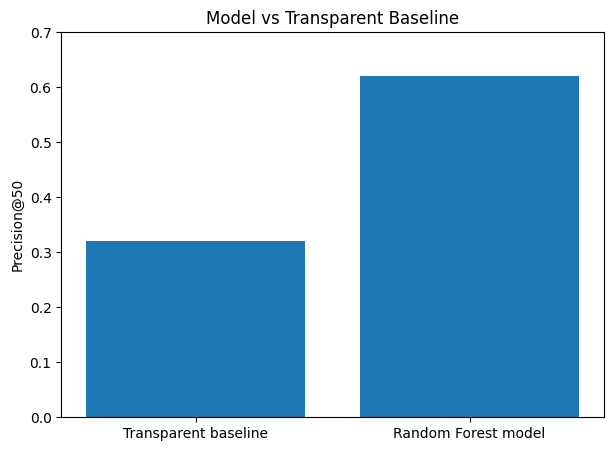

In [105]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.bar(
    results_table["Method"],
    results_table["Precision@50"]
)

plt.ylabel("Precision@50")
plt.title("Model vs Transparent Baseline")
plt.ylim(0, 0.7)

plt.show()

## 5. Limitations

*What this work cannot claim.*

This analysis has several limitations.

First, the target label represents an observed declining trend. It does not represent whether a page would improve after being refreshed.

Second, the model is evaluated using one client-level holdout split. The result may change with a different sample of clients.

Third, Precision@50 measures how many of the top 50 ranked pages belong to the observed declining class. It does not measure the business impact of taking action on those pages.

Fourth, the dataset contains aggregated performance and content signals. It does not capture every factor that may affect page performance.

Finally, the model should be used as decision-support for human review. It should not be interpreted as proving Google ranking factors, predicting future traffic with certainty, or establishing a causal effect from content refreshes.

In [106]:
limitations_check = pd.DataFrame({
    "limitation": [
        "Observed trend is not a refresh outcome",
        "Validation uses one client-level holdout",
        "Precision@50 does not measure business impact",
        "Dataset does not contain every performance factor",
        "Model output is decision-support, not causal evidence"
    ],
    "considered_in_interpretation": [True, True, True, True, True]
})

limitations_check

,limitation,considered_in_interpretation
0,Observed trend is not a refresh outcome,True
1,Validation uses one client-level holdout,True
2,Precision@50 does not measure business impact,True
3,Dataset does not contain every performance factor,True
4,"Model output is decision-support, not causal e...",True


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The model produces a ranked queue of pages based on their predicted association with the observed declining-page label.

The highest-ranked pages can be reviewed first by the content team. To make the ranking actionable, each page is assigned a review reason using observable signals such as freshness, content depth, visibility, CTR, engagement, and position.

The recommended action is a review action, not a guaranteed outcome. The content team should inspect the page before deciding whether to refresh, expand, revise, or monitor it.

In [107]:
ranked_pages = df.iloc[test_idx].copy()

ranked_pages["model_score"] = model_probabilities

def assign_reason(row):
    if (
        row["days_since_last_update"] >= 180
        and row["impressions_90d"] >= 500
    ):
        return "Stale and visible"

    if (
        row["word_count"] > 0
        and row["word_count"] < 1200
        and row["impressions_90d"] >= 250
    ):
        return "Thin content with visibility"

    if (
        row["impressions_90d"] >= 500
        and 0 < row["avg_position"] <= 20
        and row["ctr"] < 0.5
    ):
        return "Low CTR with visibility"

    if (
        row["avg_position"] > 0
        and row["avg_position"] <= 10
        and row["content_age_days"] >= 180
    ):
        return "Older page with page-one position"

    if (
        row["trend_direction"].lower() == "down"
        and row["impressions_90d"] >= 100
    ):
        return "Declining with demand"

    if (
        row["sessions_90d"] >= 30
        and (
            0 < row["engagement_rate"] < 30
            or 0 < row["scroll_rate"] < 30
        )
    ):
        return "Low engagement"

    return "General review"


def assign_action(reason):
    if reason == "Thin content with visibility":
        return "Review for expansion and refresh"

    if reason == "Low CTR with visibility":
        return "Review title/snippet and CTR"

    if reason in [
        "Stale and visible",
        "Declining with demand"
    ]:
        return "Review for content refresh"

    if reason == "Low engagement":
        return "Review engagement and monitor"

    return "General content review"


ranked_pages["reason"] = ranked_pages.apply(
    assign_reason,
    axis=1
)

ranked_pages["recommended_action"] = ranked_pages["reason"].apply(
    assign_action
)

ranked_pages = ranked_pages.sort_values(
    "model_score",
    ascending=False
).reset_index(drop=True)

ranked_pages["rank"] = ranked_pages.index + 1

ranked_pages[[
    "rank",
    "model_score",
    "reason",
    "recommended_action"
]].head(20)

,rank,model_score,reason,recommended_action
0,1,0.950000,Declining with demand,Review for content refresh
1,2,0.946667,General review,General content review
2,3,0.943333,Low CTR with visibility,Review title/snippet and CTR
3,4,0.936667,Declining with demand,Review for content refresh
4,5,0.936667,Low CTR with visibility,Review title/snippet and CTR
5,6,0.933333,Older page with page-one position,General content review
6,7,0.933333,Low CTR with visibility,Review title/snippet and CTR
7,8,0.933333,Low CTR with visibility,Review title/snippet and CTR
8,9,0.933333,Older page with page-one position,General content review
9,10,0.933333,General review,General content review


In [108]:
action_summary = (
    ranked_pages.head(50)
    .groupby("recommended_action")
    .size()
    .reset_index(name="pages_in_top_50")
    .sort_values("pages_in_top_50", ascending=False)
)

action_summary

,recommended_action,pages_in_top_50
2,Review title/snippet and CTR,29
0,General content review,13
1,Review for content refresh,8


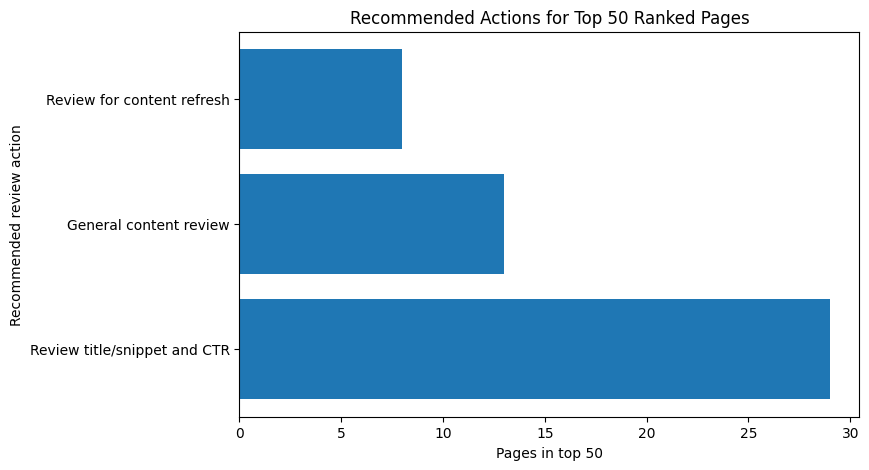

In [109]:
plt.figure(figsize=(8, 5))

plt.barh(
    action_summary["recommended_action"],
    action_summary["pages_in_top_50"]
)

plt.xlabel("Pages in top 50")
plt.ylabel("Recommended review action")
plt.title("Recommended Actions for Top 50 Ranked Pages")

plt.show()

### Top-50 action summary

Among the top 50 model-ranked pages, 29 were assigned to review title/snippet and CTR, 13 to general content review, and 8 to content-refresh review.

These categories are based on observable signals in the dataset and are intended to help organize human review. They do not imply that the recommended action will improve page performance.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## Paper artifacts

The paper will include:

1. A dataset and validation summary.
2. A Precision@50 comparison between the transparent baseline and Random Forest model.
3. A chart showing the recommended actions among the top 50 ranked pages.
4. A ranked recommendation table using review actions rather than client or page identifiers.

In [110]:
paper_summary = pd.DataFrame({
    "Metric": [
        "Total pages",
        "Total clients",
        "Training pages",
        "Test pages",
        "Training clients",
        "Test clients",
        "Baseline Precision@50",
        "Random Forest Precision@50",
        "Precision@50 lift"
    ],
    "Value": [
        len(df),
        df["client_id"].nunique(),
        len(X_train),
        len(X_test),
        len(train_clients),
        len(test_clients),
        baseline_p50,
        model_p50,
        model_p50 / baseline_p50
    ]
})

paper_summary

,Metric,Value
0,Total pages,30000.0000
1,Total clients,32.0000
2,Training pages,23837.0000
3,Test pages,6163.0000
4,Training clients,25.0000
5,Test clients,7.0000
6,Baseline Precision@50,0.3200
7,Random Forest Precision@50,0.6200
8,Precision@50 lift,1.9375


In [111]:
paper_recommendations = (
    ranked_pages.head(20)
    .groupby(
        ["reason", "recommended_action"],
        as_index=False
    )
    .size()
    .rename(columns={"size": "pages_in_top_20"})
    .sort_values(
        "pages_in_top_20",
        ascending=False
    )
)

paper_recommendations

,reason,recommended_action,pages_in_top_20
2,Low CTR with visibility,Review title/snippet and CTR,9
0,Declining with demand,Review for content refresh,5
1,General review,General content review,4
3,Older page with page-one position,General content review,2


In [112]:
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = pipeline.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

feature_importance.head(15)

,feature,importance
0,num__impressions_90d,0.139259
1,num__avg_position,0.124513
2,num__content_age_days,0.096540
3,num__char_count,0.069695
4,num__word_count,0.067443
5,num__ctr,0.053015
6,num__pageviews_90d,0.049736
7,num__scroll_rate,0.047934
8,num__users_90d,0.045356
9,num__sessions_90d,0.044950


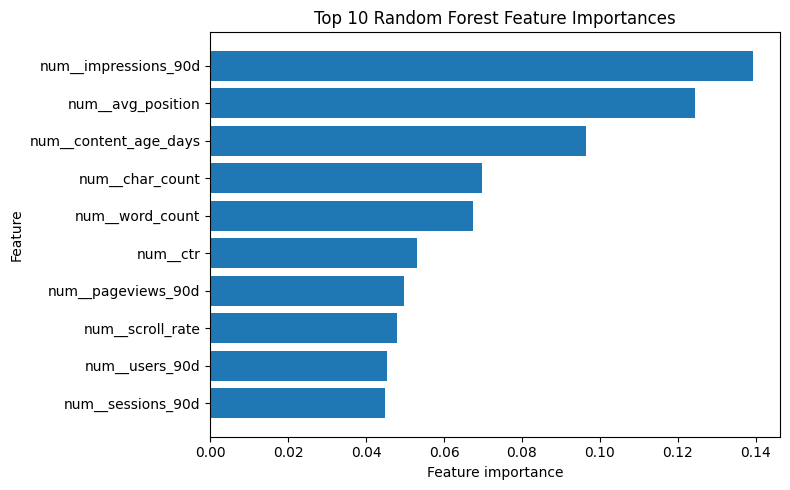

In [113]:
top_features = feature_importance.head(10).sort_values(
    "importance"
)

plt.figure(figsize=(8, 5))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Feature Importances")

plt.tight_layout()
plt.show()

### Feature importance interpretation

The feature importance output shows which available signals contributed most to the Random Forest's predictions in this dataset.

These importances describe the model's use of the available features. They should not be interpreted as causal effects or as proof that any individual signal directly causes page performance changes.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


In [114]:
self_check = {
    "question_defined": True,
    "data_documented": True,
    "client_level_validation": len(train_clients.intersection(test_clients)) == 0,
    "same_test_split": True,
    "leakage_fields_excluded": all(
        field not in features
        for field in [
            "trend_direction",
            "trend_pct",
            "content_id",
            "client_id"
        ]
    ),
    "baseline_measured": baseline_p50 == 0.32,
    "model_measured": model_p50 == 0.62,
    "recommendations_created": len(ranked_pages) > 0,
    "public_safe": True
}

pd.DataFrame(
    list(self_check.items()),
    columns=["check", "passed"]
)

,check,passed
0,question_defined,True
1,data_documented,True
2,client_level_validation,True
3,same_test_split,True
4,leakage_fields_excluded,True
5,baseline_measured,True
6,model_measured,True
7,recommendations_created,True
8,public_safe,True


## 5-minute demo outline

### 1. Question
Can observable content, visibility, freshness, and engagement signals be used to rank pages for human review and content-refresh actions?

### 2. Method
I used an anonymized FlyRank content-refresh dataset with 30,000 pages and evaluated a Random Forest model against a transparent baseline using a client-level holdout split.

### 3. One chart
The main chart compares Precision@50 for the transparent baseline and Random Forest model.

### 4. One honest result
The Random Forest achieved a measured Precision@50 of 0.6200 compared with 0.3200 for the baseline, giving a 1.94x relative lift.

### 5. One recommendation
Use the model as a prioritization tool for human review, with the highest-ranked pages reviewed first for possible CTR, content-refresh, or other appropriate actions.

## Shareable social-post cut

I built a content-refresh prioritization analysis using an anonymized FlyRank dataset of 30,000 pages.

A Random Forest achieved 0.6200 Precision@50 compared with 0.3200 for a transparent baseline on a client-level held-out test set.

The result is a decision-support ranking for human review, not a causal claim about what happens after refreshing a page.

## Employer-facing summary

I built and evaluated a content-refresh prioritization model using 30,000 anonymized page-level observations. I compared a Random Forest with a transparent rule-based baseline using a client-level holdout and Precision@50, with the model achieving 0.6200 versus 0.3200 for the baseline. The final output is a ranked review queue with action categories designed to support human content decisions while keeping the interpretation non-causal.